<a href="https://colab.research.google.com/github/onyeogulu/19175136.github.io/blob/master/Land_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The code was first written and tested on Google Colab before been move to Github.

---
## Cell 1 · Install Dependencies

In [17]:
import subprocess, sys

PACKAGES = [
    "pypdf",        # native PDF text layer
    "pdfplumber",   # layout-aware extraction
    "pdf2image",    # PDF → PIL images
    "pytesseract",  # Tesseract OCR wrapper
    "Pillow",       # image processing
    "pandas",       # tabular data
    "opencv-python-headless",  # image pre-processing
]

for pkg in PACKAGES:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "-q",
         "--break-system-packages"],
        stdout=subprocess.DEVNULL
    )

import fitz
import re
import spacy
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans


# ------------------------------
# Load NLP models
# ------------------------------

nlp = spacy.load("en_core_web_trf")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✅ All packages installed.")



✅ All packages installed.


In [25]:
!pip install pdf2image

---
## Cell 2 · Imports & Version Check

In [18]:
import os, re, json, time, shutil
from pathlib import Path

import pypdf
import pdfplumber
import pytesseract
import pandas as pd
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
from pdf2image import convert_from_path
from IPython.display import display, Image as IPImage

print(f"  pypdf           {pypdf.__version__}")
print(f"  pdfplumber      {pdfplumber.__version__}")
print(f"  pytesseract     {pytesseract.__version__}")
print(f"  Tesseract OCR   {pytesseract.get_tesseract_version()}")
print(f"  pandas          {pd.__version__}")
print(f"  OpenCV          {cv2.__version__}")

  pypdf           6.7.5
  pdfplumber      0.11.9
  pytesseract     0.3.13
  Tesseract OCR   4.1.1
  pandas          2.2.2
  OpenCV          4.13.0


---
## Cell 3 · Configuration

In [19]:
# ═══════════════════════════════════════════════════
#  USER SETTINGS — edit here
# ═══════════════════════════════════════════════════
PDF_PATH    = "/content/drive/MyDrive/Colab_Notebooks/anonymised.pdf"
OUTPUT_DIR  = Path("./content/drive/MyDrive/Colab_Notebooks/")
IMG_DIR     = OUTPUT_DIR / "page_images"

OCR_DPI     = 300      # 300 recommended; 400 for very small print
OCR_LANG    = "eng"    # Tesseract lang; e.g. "eng+fra" for multilingual
OCR_PSM     = 6        # Page segmentation mode: 6 = uniform block of text
                        # Other useful values: 3 (auto), 4 (single column)
CONF_THRESH = 40       # Minimum word confidence (0–100) for word-level output
# ═══════════════════════════════════════════════════

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

assert os.path.exists(PDF_PATH), f"❌ PDF not found: {PDF_PATH}"
print(f"✅ PDF found     : {PDF_PATH}")
print(f"   File size     : {os.path.getsize(PDF_PATH)/1024:.1f} KB")
print(f"   Output folder : {OUTPUT_DIR.resolve()}")

✅ PDF found     : /content/drive/MyDrive/Colab_Notebooks/anonymised.pdf
   File size     : 547.2 KB
   Output folder : /content/content/drive/MyDrive/Colab_Notebooks


---
## Cell 4 · PDF Metadata

In [20]:
reader  = pypdf.PdfReader(PDF_PATH)
meta    = reader.metadata
N_PAGES = len(reader.pages)

metadata_dict = {
    "file"        : PDF_PATH,
    "pages"       : N_PAGES,
    "title"       : meta.title    or "N/A",
    "author"      : meta.author   or "N/A",
    "subject"     : meta.subject  or "N/A",
    "creator"     : meta.creator  or "N/A",
    "producer"    : meta.producer or "N/A",
    "filesize_kb" : round(os.path.getsize(PDF_PATH) / 1024, 1),
}

print("┌─────────────────────────────────────┐")
print("│           PDF  METADATA             │")
print("├─────────────────────────────────────┤")
for k, v in metadata_dict.items():
    print(f"│  {k:<14}: {str(v):<20} │")
print("└─────────────────────────────────────┘")

┌─────────────────────────────────────┐
│           PDF  METADATA             │
├─────────────────────────────────────┤
│  file          : /content/drive/MyDrive/Colab_Notebooks/anonymised.pdf │
│  pages         : 4                    │
│  title         : anonymised           │
│  author        : N/A                  │
│  subject       : N/A                  │
│  creator       : N/A                  │
│  producer      : N/A                  │
│  filesize_kb   : 547.2                │
└─────────────────────────────────────┘


---
## Cell 5 · Render Pages to Images
Each PDF page is rasterised to a high-resolution PIL image. This is the key step for scanned documents.

In [28]:
print(f"Converting {N_PAGES} page(s) to images at {OCR_DPI} DPI …")
t0 = time.time()

# Install poppler-utils if not already installed
import subprocess
try:
    subprocess.run(['pdfinfo', '-v'], check=True, capture_output=True)
except FileNotFoundError:
    print("Poppler-utils not found. Installing now...")
    subprocess.run(['apt-get', 'update'], check=True)
    subprocess.run(['apt-get', 'install', '-y', 'poppler-utils'], check=True)
    print("Poppler-utils installed.")

page_images = convert_from_path(PDF_PATH, dpi=OCR_DPI)

# Save each page as PNG
image_paths = []
for i, img in enumerate(page_images):
    path = IMG_DIR / f"page_{i+1:02d}.png"
    img.save(path, "PNG")
    image_paths.append(path)
    print(f"  Page {i+1}: {img.size[0]}×{img.size[1]} px  →  {path.name}")

print(f"\n✅ Rendered in {time.time()-t0:.1f}s")

Converting 4 page(s) to images at 300 DPI …
Poppler-utils not found. Installing now...
Poppler-utils installed.
  Page 1: 7763×5471 px  →  page_01.png
  Page 2: 3025×4280 px  →  page_02.png
  Page 3: 3092×4384 px  →  page_03.png
  Page 4: 3109×4409 px  →  page_04.png

✅ Rendered in 24.4s


---
## Cell 6 · Preview Page Thumbnails
Displays a thumbnail of each page inline.


──────────────────────────────────────────────────
 PAGE 1
──────────────────────────────────────────────────


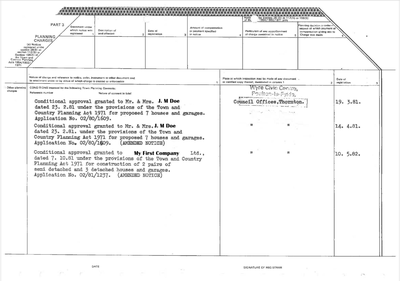


──────────────────────────────────────────────────
 PAGE 2
──────────────────────────────────────────────────


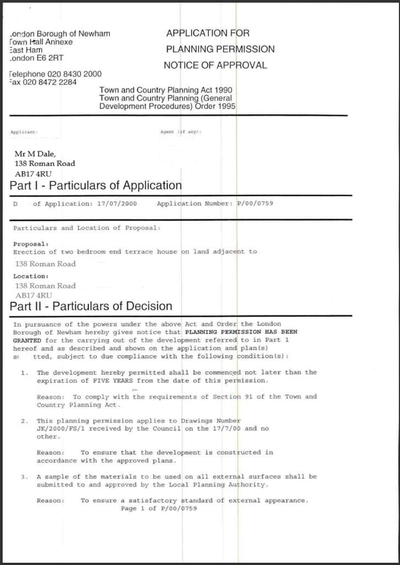


──────────────────────────────────────────────────
 PAGE 3
──────────────────────────────────────────────────


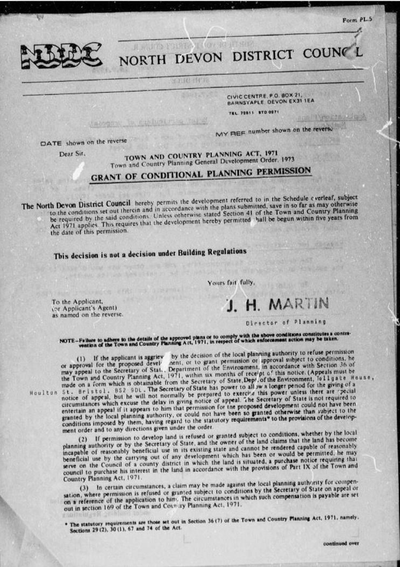


──────────────────────────────────────────────────
 PAGE 4
──────────────────────────────────────────────────


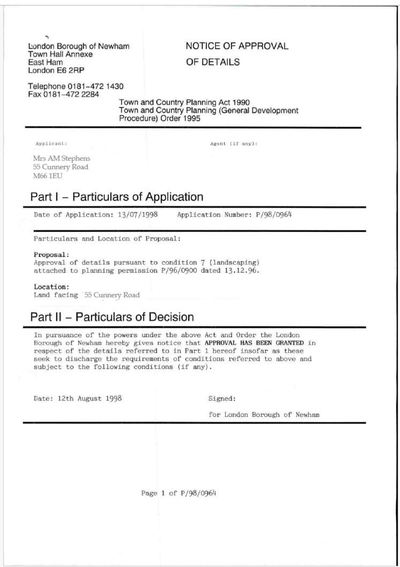

In [29]:
THUMB_WIDTH = 400  # pixels

for i, img in enumerate(page_images):
    ratio = THUMB_WIDTH / img.width
    thumb = img.resize((THUMB_WIDTH, int(img.height * ratio)), Image.LANCZOS)
    print(f"\n{'─'*50}")
    print(f" PAGE {i+1}")
    print(f"{'─'*50}")
    display(thumb)

---
## Cell 7 · Image Pre-processing for OCR
Applies grayscale conversion, denoising, and adaptive thresholding — proven to significantly improve Tesseract accuracy on old/scanned documents.

Original (left)  vs  Pre-processed (right) — Page 1


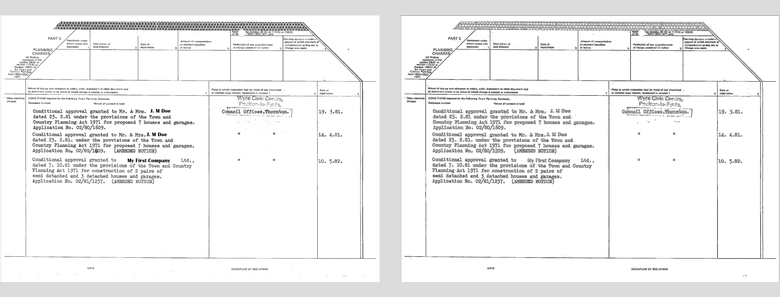

In [32]:
def preprocess_for_ocr(pil_image: Image.Image) -> Image.Image:
    """
    Pipeline:
      1. Grayscale
      2. Mild sharpening
      3. OpenCV adaptive threshold (handles uneven lighting)
      4. Morphological opening (removes specks)
    Returns a PIL Image ready for Tesseract.
    """
    # Step 1 — grayscale
    gray = pil_image.convert("L")

    # Step 2 — sharpen
    sharpened = ImageEnhance.Sharpness(gray).enhance(2.0)

    # Step 3 — numpy / OpenCV
    arr = np.array(sharpened)
    blurred = cv2.GaussianBlur(arr, (3, 3), 0)
    thresh  = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=15, C=8
    )

    # Step 4 — morphological opening
    kernel  = np.ones((1, 1), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    return Image.fromarray(cleaned)


# Preview pre-processed page 1
raw_page1  = page_images[0]
proc_page1 = preprocess_for_ocr(raw_page1)

print("Original (left)  vs  Pre-processed (right) — Page 1")
# Side-by-side comparison at thumbnail scale
W = 380
def thumb(img, w=W):
    r = w / img.width
    return img.resize((w, int(img.height*r)), Image.LANCZOS)

comparison = Image.new("RGB",
    (W*2 + 20, thumb(proc_page1.convert("RGB")).height + 30),
    (220, 220, 220))
comparison.paste(thumb(raw_page1.convert("RGB")), (0, 15))
comparison.paste(thumb(proc_page1.convert("RGB")), (W+20, 15))
display(comparison)

---
## Cell 8 · Method C — Full-Page OCR (pytesseract)

In [33]:
def clean_ocr_text(text: str) -> str:
    """Normalise whitespace and strip control chars from OCR output."""
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def ocr_page(pil_image: Image.Image, lang: str, psm: int) -> str:
    """Pre-process then OCR a single page image."""
    processed = preprocess_for_ocr(pil_image)
    config    = f"--psm {psm} --oem 3"  # oem 3 = LSTM + legacy engine
    raw       = pytesseract.image_to_string(processed, lang=lang, config=config)
    return clean_ocr_text(raw)


print(f"OCR settings: DPI={OCR_DPI}, lang={OCR_LANG}, psm={OCR_PSM}")
print("─" * 50)

ocr_results = []
for i, img in enumerate(page_images):
    t0   = time.time()
    text = ocr_page(img, OCR_LANG, OCR_PSM)
    elapsed = round(time.time() - t0, 2)
    ocr_results.append({
        "page": i + 1, "method": "ocr",
        "char_count": len(text),
        "word_count": len(text.split()),
        "elapsed_s": elapsed,
        "text": text
    })
    print(f"  Page {i+1}: {len(text):>6} chars | {len(text.split()):>5} words | {elapsed:.1f}s")

print("\n✅ OCR complete.")

OCR settings: DPI=300, lang=eng, psm=6
──────────────────────────────────────────────────
  Page 1:   1950 chars |   391 words | 20.6s
  Page 2:   1751 chars |   299 words | 10.8s
  Page 3:   4317 chars |   848 words | 26.0s
  Page 4:   1087 chars |   169 words | 9.3s

✅ OCR complete.


## Cell 9 · Extract Applicant Number Using Partterns

In [80]:
pages = []
for i in ocr_results:
  pages.append({"page_number": i["page"], "text": i["text"]})

In [81]:
def extract_application_numbers(text):

    patterns = [
        r"\b\d{2}/\d{2}/\d{4,6}\b",
        r"P/\d{2}/\d{4}",
        r"\b[A-Z]{1}/\d{2}/\d{4}\b",
        r"application\s*no\.?\s*[:\-]?\s*([A-Za-z0-9\/\-]+)"
    ]

    results = []

    for pattern in patterns:
        matches = re.findall(pattern, text, flags=re.IGNORECASE)
        results.extend(matches)

    return list(set(results))

In [115]:
App_No = []
for i in pages:
  App_No.append({"page_number": i["page_number"], "Application No": extract_application_numbers(i['text'])})
print(App_No)

Application_Number = pd.DataFrame(App_No)
Application_Number

[{'page_number': 1, 'Application No': ['o', '02/80/1609', '02/80/1009']}, {'page_number': 2, 'Application No': ['17/07/2000']}, {'page_number': 3, 'Application No': []}, {'page_number': 4, 'Application No': ['13/07/1998', 'P/98/0964']}]


,page_number,Application No
0,1,"[o, 02/80/1609, 02/80/1009]"
1,2,[17/07/2000]
2,3,[]
3,4,"[13/07/1998, P/98/0964]"


## Cell 10 · Extract Applicant Name Using Partterns

In [92]:
def extract_applicant_names(text):

    doc = nlp(text)

    names = []

    for ent in doc.ents:

        if ent.label_ == "PERSON":
            names.append(ent.text)

        # if ent.label_ == "ORG":
        #     names.append(ent.text)

    return list(set(names))

In [114]:
App_Name = []
for i in pages:
  App_Name.append({"page_number": i["page_number"], "Applicant Name": extract_applicant_names(i['text'])})
print(App_Name)


Applicants_Name = pd.DataFrame(App_Name)
Applicants_Name

[{'page_number': 1, 'Applicant Name': ['Saisie', 'Mee.', 'ef me', 'Beene', 'Mo', 'nautica', 'Chewewasmede']}, {'page_number': 2, 'Applicant Name': ['heveby', 'BEER']}, {'page_number': 3, 'Applicant Name': ['Couaine Phinning', 'ihe Seerelary', 'Prana ae\net', 'Leen', 'OUerWiHE', 'mae bensenty.ake', 'irmepalreel Hs', 'holler', 'peenuisslon ds jefuced', 'ecelp lof ihis', 'miblec', 'via fhesdtar', 'ee Pa rs\n', 'icenrdoaew withthe', 'the-Schedwleewerleat', 'eu Yee Oa De Py', 'slay', 'tie nitdigondhons', 'ihe Tews', 'permissien Tar', 'a Tian', 'dewelapime', 'wally sie ananthae']}, {'page_number': 4, 'Applicant Name': ['Ack', 'AIM Stephens', 'Por London Borguen', 'FastHany', 'pernisston']}]


,page_number,Applicant Name
0,1,"[Saisie, Mee., ef me, Beene, Mo, nautica, Chew..."
1,2,"[heveby, BEER]"
2,3,"[Couaine Phinning, ihe Seerelary, Prana ae\net..."
3,4,"[Ack, AIM Stephens, Por London Borguen, FastHa..."


## Cell 11 · Classify Pages into Three Cluster

In [117]:
def preprocess_text(text):
  doc = nlp(text)
  tokens = [token.lemma_.lower()
  for token in doc
            if token.is_alpha and not token.is_stop]

  return " ".join(tokens)

def classify_page_types(pages, n_clusters=3):

    clean_texts = [preprocess_text(p["text"]) for p in pages]

    embeddings = embedding_model.encode(clean_texts)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)

    labels = kmeans.fit_predict(embeddings)

    for i, page in enumerate(pages):
        page["page_cluster"] = int(labels[i])

    return pages




In [120]:
pages = classify_page_types(pages)

page_cluster = []
for i in pages:
  page_cluster.append({"page_number": i["page_number"], "Cluster": i['page_cluster']})


print(page_cluster)

Cluster = pd.DataFrame(page_cluster)
print(Cluster)

[{'page_number': 1, 'Cluster': 2}, {'page_number': 2, 'Cluster': 0}, {'page_number': 3, 'Cluster': 1}, {'page_number': 4, 'Cluster': 0}]
   page_number  Cluster
0            1        2
1            2        0
2            3        1
3            4        0
